In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.linalg import expm, solve_continuous_lyapunov
from scipy.optimize import minimize_scalar

from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

price_resid = pd.read_csv("../data/deseasonalised/price_resid.csv", index_col=0)

price_res = price_resid["price_deseasoned"].copy()
time_price = price_res.index.copy()

# conversion en numpy + centrage
y = price_res.astype(float).values
print(np.mean(y))
y = y - np.mean(y)

print("Taille de la série :", len(y))
print("Moyenne après centrage :", np.mean(y))
print("Variance :", np.var(y))

def buildcompanion(a):
    """
    Construit la matrice compagnon associée à a = [a1, ..., ap]
    Dans le cas p=2 :
        A = [[0, 1],
             [-a2, -a1]]
    """
    p = len(a)
    A = np.zeros((p, p))
    
    for i in range(p - 1):
        A[i, i + 1] = 1.0

    A[p - 1, :] = -np.array(a[::-1], dtype=float)
    return A


def buildsigma(coefcarma):
    """
    Résout l'équation de Lyapunov continue :
        A Sigma + Sigma A^T + e_p e_p^T = 0
    """
    A = buildcompanion(coefcarma)
    p = len(coefcarma)

    ep = np.zeros((p, 1))
    ep[p - 1, 0] = 1.0

    Q = ep @ ep.T

    sigma = solve_continuous_lyapunov(A, -Q)
    return sigma

def theoretical_acf(A, Sigma, b, h, K):
    """
    Calcule l'ACF théorique rho_0, ..., rho_K
    pour un vecteur b donné.
    """
    gamma = []

    for k in range(K + 1):
        expA = expm(A * (k * h))
        gk = b.T @ Sigma @ expA @ b
        gamma.append(float(gk))

    gamma = np.array(gamma, dtype=float)

    if np.isclose(gamma[0], 0.0):
        raise ValueError("gamma[0] est trop proche de 0.")

    rho = gamma / gamma[0]
    return rho

def objective_b0(b0, A, Sigma, h, rho_emp, K):
    b = np.array([[b0], [1.0],[0.0]])
    rho_th = theoretical_acf(A, Sigma, b, h, K)

    # on compare à partir du lag 1
    return np.sum(np.abs(rho_emp[1:] - rho_th[1:]))

def estimate_b0(y, a, h, K=50, bounds=(-10, 10)):
    """
    Estime b0 pour un CARMA(2,1) avec b1 = 1
    par appariement de l'ACF.
    """
    A = buildcompanion(a)
    Sigma = buildsigma(a)
    rho_emp = acf(y, nlags=K, fft=True)

    result = minimize_scalar(
        objective_b0,
        args=(A, Sigma, h, rho_emp, K),
        bounds=bounds,
        method="bounded"
    )

    b0_hat = result.x
    obj_value = result.fun

    return {
        "b0_hat": b0_hat,
        "objective_value": obj_value,
        "success": result.success,
        "message": result.message,
        "A": A,
        "Sigma": Sigma,
        "rho_emp": rho_emp
    }
    
    def estimate_b0(y, a, h, K=50, bounds=(-10, 10)):
    """
    Estime b0 pour un CARMA(2,1) avec b1 = 1
    par appariement de l'ACF.
    """
    A = buildcompanion(a)
    Sigma = buildsigma(a)
    rho_emp = acf(y, nlags=K, fft=True)

    result = minimize_scalar(
        objective_b0,
        args=(A, Sigma, h, rho_emp, K),
        bounds=bounds,
        method="bounded"
    )

    b0_hat = result.x
    obj_value = result.fun

    return {
        "b0_hat": b0_hat,
        "objective_value": obj_value,
        "success": result.success,
        "message": result.message,
        "A": A,
        "Sigma": Sigma,
        "rho_emp": rho_emp
    }
    
    # À REMPLACER par tes vraies valeurs
a1 = 1.22281589
a2 = 0.44118817
a3=0.00934219
a = [a1, a2,a3]

h = 1.0   # à adapter à ton pas d'échantillonnage
K = 50

res = estimate_b0(y=y, a=a, h=h, K=K, bounds=(-10, 10))

print("Succès optimisation :", res["success"])
print("Message :", res["message"])
print("b0 estimé =", res["b0_hat"])
print("Valeur du critère =", res["objective_value"])
print("A =\n", res["A"])
print("Sigma =\n", res["Sigma"])

b0_hat = res["b0_hat"]
A = res["A"]
Sigma = res["Sigma"]
rho_emp = res["rho_emp"]

b_hat=np.array([[b0_hat], [1.0],[0.0]])
rho_th_hat = theoretical_acf(A, Sigma, b_hat, h, K)

lags = np.arange(K + 1)

plt.figure(figsize=(8, 4))
plt.plot(lags, rho_emp, "o-", label="ACF empirique")
plt.plot(lags, rho_th_hat, "s--", label="ACF théorique ajustée")
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Lag")
plt.ylabel("Autocorrélation")
plt.title("CARMA(3,1) : ACF empirique vs théorique")
plt.legend()
plt.grid(True)
plt.show()

print("ACF empirique :", rho_emp)
print("ACF théorique :", rho_th_hat)

b0_grid = np.linspace(-10, 5, 400)
obj_grid = [
    objective_b0(b0, A, Sigma, h, rho_emp, K)
    for b0 in b0_grid
]

plt.figure(figsize=(8, 4))
plt.plot(b0_grid, obj_grid)
plt.axvline(b0_hat, linestyle="--", label=f"b0_hat = {b0_hat:.4f}")
plt.xlabel("b0")
plt.ylabel("Critère L1")
plt.title("Fonction objectif")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
import numpy as np
import pandas as pd

from scipy.linalg import expm, solve_continuous_lyapunov
from scipy.optimize import differential_evolution, minimize
from statsmodels.tsa.stattools import acf

# ============================================================
# PARAMÈTRES À FIXER
# ============================================================
AR_COEFS = np.array([2.09528759, 8.7388716, 0.77718031], dtype=float)   # coefficients AR fixés
H = 1.0                 # pas d'échantillonnage
K = 50                  # nombre de lags utilisés pour l'ajustement
BOUNDS = [(-20, 20), (-20, 20)]   # bornes de recherche pour (b1, b2)

# ============================================================
# DONNÉES
# ============================================================
price_resid = pd.read_csv("../data/deseasonalised/price_resid.csv", index_col=0)
y = price_resid["price_deseasoned"].astype(float).values
y = y - np.mean(y)

# ============================================================
# OUTILS CARMA
# ============================================================
def build_companion(a):
    """
    Matrice compagnon pour le polynôme AR:
    a = [a1, ..., ap]
    """
    p = len(a)
    A = np.zeros((p, p), dtype=float)
    A[:-1, 1:] = np.eye(p - 1)
    A[-1, :] = -np.asarray(a[::-1], dtype=float)
    return A

def build_sigma(a):
    """
    Résout l'équation de Lyapunov continue :
        A Sigma + Sigma A^T + e_p e_p^T = 0
    """
    A = build_companion(a)
    p = len(a)

    e_p = np.zeros((p, 1), dtype=float)
    e_p[-1, 0] = 1.0
    Q = e_p @ e_p.T

    Sigma = solve_continuous_lyapunov(A, -Q)
    return Sigma

def theoretical_acf(A, Sigma, b, h, K):
    """
    Calcule rho(0), ..., rho(K)
    avec b vecteur colonne.
    """
    gamma = np.empty(K + 1, dtype=float)

    for k in range(K + 1):
        expA = expm(A * (k * h))
        gamma[k] = float(b.T @ Sigma @ expA @ b)

    if not np.isfinite(gamma[0]) or abs(gamma[0]) < 1e-14:
        raise ValueError("gamma[0] invalide ou trop proche de 0.")

    rho = gamma / gamma[0]
    return rho

# ============================================================
# ESTIMATION ROBUSTE DE b1, b2 AVEC b0 = 1
# ============================================================
def estimate_ma_coeffs_robust(y, ar_coefs, h=1.0, K=15, bounds=None):
    """
    Estime les coefficients MA avec b0 = 1 fixé.
    Ici b = [1, b1, b2]^T.

    Méthode :
    - ACF empirique
    - optimisation globale (differential_evolution)
    - raffinement local (L-BFGS-B)
    """

    if bounds is None:
        bounds = [(-20, 20), (-20, 20)]

    A = build_companion(ar_coefs)
    Sigma = build_sigma(ar_coefs)
    rho_emp = acf(y, nlags=K, fft=True)

    # poids décroissants : on peut privilégier les petits lags,
    # souvent plus informatifs et plus stables
    weights = 1.0 / (1.0 + np.arange(1, K + 1))

    def objective(params):
        b1, b2 = params
        b = np.array([[1.0], [b1], [b2]], dtype=float)

        try:
            rho_th = theoretical_acf(A, Sigma, b, h, K)
        except Exception:
            return 1e12

        diff = rho_emp[1:] - rho_th[1:]

        if not np.all(np.isfinite(diff)):
            return 1e12

        # Critère L2 pondéré : plus lisse et stable numériquement
        return np.sum(weights * diff**2)

    # ----------------------------
    # 1) Recherche globale
    # ----------------------------
    global_res = differential_evolution(
        objective,
        bounds=bounds,
        strategy="best1bin",
        maxiter=1000,
        popsize=25,
        tol=1e-8,
        mutation=(0.5, 1.0),
        recombination=0.7,
        polish=False,
        seed=42,
        updating="deferred",
        workers=1
    )

    # ----------------------------
    # 2) Raffinement local
    # ----------------------------
    local_res = minimize(
        objective,
        x0=global_res.x,
        method="L-BFGS-B",
        bounds=bounds,
        options={
            "maxiter": 5000,
            "ftol": 1e-14,
            "gtol": 1e-10
        }
    )

    b1_hat, b2_hat = local_res.x
    b_hat = np.array([1.0, b1_hat, b2_hat], dtype=float)

    return {
        "ar_coefs": np.asarray(ar_coefs, dtype=float),
        "ma_coefs_hat": b_hat,
        "b1_hat": b1_hat,
        "b2_hat": b2_hat,
        "objective_value": local_res.fun,
        "success": local_res.success,
        "message": local_res.message,
        "global_start": global_res.x,
        "A": A,
        "Sigma": Sigma,
        "rho_emp": rho_emp
    }

# ============================================================
# LANCEMENT
# ============================================================
res = estimate_ma_coeffs_robust(
    y=y,
    ar_coefs=AR_COEFS,
    h=H,
    K=K,
    bounds=BOUNDS
)

# sortie principale
res["ma_coefs_hat"]

C:\Users\gabri\AppData\Local\Temp\ipykernel_29140\3090511985.py:61: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma[k] = float(b.T @ Sigma @ expA @ b)


array([1.        , 0.23152687, 0.14404235])

C:\Users\gabri\AppData\Local\Temp\ipykernel_29140\3742437980.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma[k] = float(b.T @ Sigma @ expm(A * (k * h)) @ b)


b_hat = [1.         0.79653224 0.12029408]
c_hat = 0.23925168354497653
critère = 0.14809929905276423
succès = True
message = CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


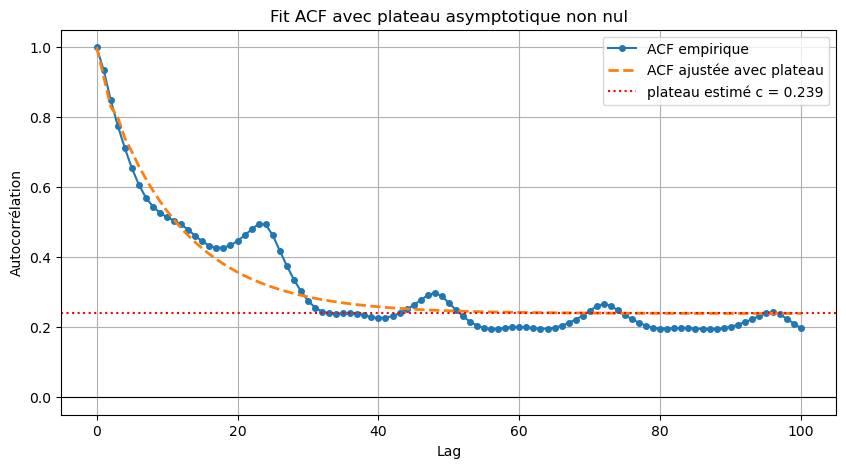

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.linalg import expm, solve_continuous_lyapunov
from scipy.optimize import differential_evolution, minimize
from statsmodels.tsa.stattools import acf

# ============================================================
# PARAMÈTRES
# ============================================================
AR_COEFS = np.array([2.09528759, 8.7388716, 0.77718031], dtype=float)
H = 1.0
K = 100

# bornes pour (b1, b2, c)
# c = niveau asymptotique de l'ACF
BOUNDS = [(-50, 50), (-50, 50), (0.0, 0.5)]

# ============================================================
# DONNÉES
# ============================================================
price_resid = pd.read_csv("../data/deseasonalised/price_resid.csv", index_col=0)
y = price_resid["price_deseasoned"].astype(float).values
y = y - np.mean(y)

# ============================================================
# OUTILS CARMA
# ============================================================
def build_companion(a):
    p = len(a)
    A = np.zeros((p, p), dtype=float)
    A[:-1, 1:] = np.eye(p - 1)
    A[-1, :] = -np.asarray(a[::-1], dtype=float)
    return A

def build_sigma(a):
    A = build_companion(a)
    p = len(a)

    e_p = np.zeros((p, 1), dtype=float)
    e_p[-1, 0] = 1.0
    Q = e_p @ e_p.T

    Sigma = solve_continuous_lyapunov(A, -Q)
    return Sigma

def theoretical_acf_carma(A, Sigma, b, h, K):
    gamma = np.empty(K + 1, dtype=float)

    for k in range(K + 1):
        gamma[k] = float(b.T @ Sigma @ expm(A * (k * h)) @ b)

    if (not np.isfinite(gamma[0])) or abs(gamma[0]) < 1e-14:
        raise ValueError("gamma[0] invalide.")

    return gamma / gamma[0]

def shifted_acf_model(rho_carma, c):
    """
    Modèle d'ACF avec plateau asymptotique c :
        rho_model(k) = c + (1-c)*rho_carma(k)
    ce qui garantit :
        rho_model(0) = 1
        rho_model(inf) = c
    """
    return c + (1.0 - c) * rho_carma

# ============================================================
# ESTIMATION
# ============================================================
def estimate_ma_with_plateau(y, ar_coefs, h=1.0, K=100, bounds=None):
    if bounds is None:
        bounds = [(-50, 50), (-50, 50), (0.0, 0.5)]

    A = build_companion(ar_coefs)
    Sigma = build_sigma(ar_coefs)
    rho_emp = acf(y, nlags=K, fft=True)

    # un petit poids décroissant reste utile, mais on garde tous les lags
    weights = 1.0 / (1.0 + 0.02 * np.arange(1, K + 1))

    def objective(params):
        b1, b2, c = params
        b = np.array([[1.0], [b1], [b2]], dtype=float)

        try:
            rho_carma = theoretical_acf_carma(A, Sigma, b, h, K)
            rho_model = shifted_acf_model(rho_carma, c)
        except Exception:
            return 1e15

        diff = rho_emp[1:] - rho_model[1:]

        if not np.all(np.isfinite(diff)):
            return 1e15

        return np.sum(weights * diff**2)

    # optimisation globale
    global_res = differential_evolution(
        objective,
        bounds=bounds,
        strategy="best1bin",
        maxiter=1200,
        popsize=30,
        tol=1e-8,
        mutation=(0.5, 1.0),
        recombination=0.7,
        polish=False,
        seed=42,
        updating="deferred",
        workers=1
    )

    # raffinement local
    local_res = minimize(
        objective,
        x0=global_res.x,
        method="L-BFGS-B",
        bounds=bounds,
        options={
            "maxiter": 8000,
            "ftol": 1e-15,
            "gtol": 1e-12
        }
    )

    b1_hat, b2_hat, c_hat = local_res.x
    b_hat = np.array([1.0, b1_hat, b2_hat], dtype=float)

    rho_carma_hat = theoretical_acf_carma(A, Sigma, b_hat.reshape(-1, 1), h, K)
    rho_model_hat = shifted_acf_model(rho_carma_hat, c_hat)

    return {
        "ar_coefs": np.asarray(ar_coefs, dtype=float),
        "ma_coefs_hat": b_hat,
        "b1_hat": b1_hat,
        "b2_hat": b2_hat,
        "c_hat": c_hat,
        "objective_value": local_res.fun,
        "success": local_res.success,
        "message": local_res.message,
        "A": A,
        "Sigma": Sigma,
        "rho_emp": rho_emp,
        "rho_carma_hat": rho_carma_hat,
        "rho_model_hat": rho_model_hat
    }

# ============================================================
# LANCEMENT
# ============================================================
res = estimate_ma_with_plateau(
    y=y,
    ar_coefs=AR_COEFS,
    h=H,
    K=K,
    bounds=BOUNDS
)

print("b_hat =", res["ma_coefs_hat"])
print("c_hat =", res["c_hat"])
print("critère =", res["objective_value"])
print("succès =", res["success"])
print("message =", res["message"])

# ============================================================
# VISUALISATION
# ============================================================
lags = np.arange(K + 1)

plt.figure(figsize=(10, 5))
plt.plot(lags, res["rho_emp"], "o-", ms=4, label="ACF empirique")
plt.plot(lags, res["rho_model_hat"], "--", lw=2, label="ACF ajustée avec plateau")
plt.axhline(res["c_hat"], color="red", linestyle=":", label=f"plateau estimé c = {res['c_hat']:.3f}")
plt.axhline(0, color="black", lw=0.8)

plt.xlabel("Lag")
plt.ylabel("Autocorrélation")
plt.title("Fit ACF avec plateau asymptotique non nul")
plt.grid(True)
plt.legend()
plt.show()